# Problem 2

## Benders decomposition

In [6]:
import gurobipy as gp
from gurobipy import GRB

def solve_benders_fuel_procurement():
    # ------------------
    # 1) Problem Data
    fuels = ["coal", "gas"]
    scenarios = ["low", "med", "high"]

    D1 = 850.0
    D2 = {"low": 530.0, "med": 780.0, "high": 950.0}
    prob = {"low": 0.3, "med": 0.4, "high": 0.3}
    base_price = {"coal": 4.5, "gas": 5.1}
    scen_price = {
        ("coal", "low"): 3.0,
        ("coal", "med"): 6.0,
        ("coal", "high"): 7.5,
        ("gas", "low"): 4.0,
        ("gas", "med"): 5.5,
        ("gas", "high"): 8.5,
    }

    # ----------------------
    # 2) Master Problem
    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)

    # First-stage variables: y_coal, y_gas >= 0 (Year 1 procurement)
    y = master.addVars(fuels, lb=0.0, name="y")
    # Alpha >= 0 for expected second-stage cost
    alpha = master.addVar(lb=0.0, name="alpha")

    # Base-year demand constraint (equality)
    master.addConstr(gp.quicksum(y[f] for f in fuels) == D1, name="BaseYearDemand")

    # Master objective: Minimize Year 1 cost + alpha
    master.setObjective(
        gp.quicksum(base_price[f] * y[f] for f in fuels) + alpha,
        GRB.MINIMIZE
    )
    master.update()

    # ----------------------
    # 3) Benders Iteration
    max_iters = 20
    tol = 1e-6
    LB, UB = -float('inf'), float('inf')
    iteration = 0
    best_y = None

    while iteration < max_iters and (UB - LB) > tol:
        iteration += 1
        master.optimize()
        if master.status != GRB.OPTIMAL:
            print("Master infeasible or unbounded at iteration", iteration)
            break

        # Record lower bound
        LB = max(LB, master.ObjVal)
        y_sol = {f: y[f].X for f in fuels}

        # Prepare for new cut
        cut_rhs = 0.0
        cut_coeff = {f: 0.0 for f in fuels}

        # Solve each subproblem
        expected_cost = 0.0
        for s in scenarios:
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)

            # z[f,s] >= 0
            z = subp.addVars(fuels, lb=0.0, name="z")

            # Total demand
            total_dem = D1 + D2[s]
            subp.addConstr(gp.quicksum(y_sol[f] + z[f] for f in fuels) == total_dem, name="demand")
            # Balanced mix
            for f in fuels:
                subp.addConstr(y_sol[f] + z[f] >= (1/3)*total_dem, name=f"min_{f}")
                subp.addConstr(y_sol[f] + z[f] <= (2/3)*total_dem, name=f"max_{f}")

            # Objective
            subp.setObjective(gp.quicksum(scen_price[f,s] * z[f] for f in fuels), GRB.MINIMIZE)
            subp.optimize()

            if subp.status != GRB.OPTIMAL:
                print(f"Subproblem {s} infeasible")
                return

            # Duals
            pi_d = subp.getConstrByName("demand").Pi
            pi_min = {f: subp.getConstrByName(f"min_{f}").Pi for f in fuels}
            pi_max = {f: subp.getConstrByName(f"max_{f}").Pi for f in fuels}
            scen_cost = subp.ObjVal
            expected_cost += prob[s] * scen_cost

            # Build cut terms
            # Constant part: p_s * [π_d *total_dem + sum(π_min[f]*(1/3)*total_dem - π_max[f]*(2/3)*total_dem)]
            const_s = prob[s] * (
                pi_d * total_dem
                + sum(pi_min[f] * (1/3)*total_dem - pi_max[f] * (2/3)*total_dem
                      for f in fuels)
            )
            cut_rhs += const_s

            # Coefficients on y[f]
            for f in fuels:
                # coefficient = p_s*(π_max[f] - π_min[f] - π_d)
                cut_coeff[f] += prob[s] * (pi_max[f] - pi_min[f] - pi_d)

        # Record upper bound
        first_stage_cost = sum(base_price[f]*y_sol[f] for f in fuels)
        UB = min(UB, first_stage_cost + expected_cost)
        best_y = y_sol

        # Add Benders cut
        master.addConstr(
            alpha >= cut_rhs
                    + gp.quicksum(cut_coeff[f] * y[f] for f in fuels),
            name=f"BendersCut_{iteration}"
        )
        master.update()

        gap = (UB - LB)/abs(UB) if UB != 0 else 0
        print(f"Iter {iteration}: LB={LB:.4f}, UB={UB:.4f}, Gap={gap:.4%}")

    # Output final
    print("\nFinished Benders after", iteration, "iterations")
    print("Optimal Year1:", best_y)
    print("Cost =", LB)

if __name__ == "__main__":
    solve_benders_fuel_procurement()


Iter 1: LB=3825.0000, UB=8473.5000, Gap=54.8593%
Iter 2: LB=8725.5000, UB=8473.5000, Gap=-2.9740%

Finished Benders after 2 iterations
Optimal Year1: {'coal': 850.0, 'gas': 0.0}
Cost = 8725.5


In [1]:
# Benders approach:
#   - Master: y_coal, y_gas, alpha
#   - Subproblem (for each scenario): fix y_coal,y_gas, solve LP -> dual -> Benders cut.
# ---------------------------------------------------------
import gurobipy as gp
from gurobipy import GRB

def solve_benders_fuel_procurement():
    # ------------------
    # 1) Problem Data

    fuels = ["coal", "gas"]
    scenarios = ["low", "med", "high"]

    D1 = 850.0
    D2 = {"low": 530.0, "med": 780.0, "high": 950.0}
    prob = {"low": 0.3, "med": 0.4, "high": 0.3}
    base_price = {"coal": 4.5, "gas": 5.1}
    scen_price = {
        ("coal", "low"): 3.0,
        ("coal", "med"): 6.0,
        ("coal", "high"): 7.5,
        ("gas", "low"): 4.0,
        ("gas", "med"): 5.5,
        ("gas", "high"): 8.5,
    }

    # ----------------------
    # 2) Master Problem

    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)

    # First-stage variables: x_coal, x_gas >= 0 (Year 1 procurement)
    y = master.addVars(fuels, lb=0.0, name="y")

    # Alpha >= 0 for expected second-stage cost
    alpha = master.addVar(lb=0.0, name="Alpha")

    # Base-year demand constraint
    master.addConstr(gp.quicksum(y[f] for f in fuels) >= D1, name="BaseYearDemand")

    ## very important constraints to be added to constrain first year purchases from taking up
    ##  too much demand
    for s in scenarios:
        for f in fuels:
            master.addConstr(y[f] <= (2/3) * (D1 + D2[s]), name=f"FeasCut_{f}_{s}")
            
    master.update()

    # Master objective: Minimize Year 1 cost + alpha
    master.setObjective(
        gp.quicksum(base_price[f] * y[f] for f in fuels) + alpha,
        GRB.MINIMIZE,
    )
    master.update()

    # ----------------------
    # 3) Benders Iteration

    max_iters = 10
    tol = 1e-6
    iteration = 0
    LB = -float("inf")
    UB = float("inf")
    best_y1 = None

    while iteration < max_iters and (UB - LB) > tol:
        iteration += 1
        master.optimize()

        if master.status != GRB.OPTIMAL:
            print(f"Master problem infeasible or unbounded at iteration {iteration}!")
            break

        master_obj_val = master.ObjVal
        LB = max(LB, master_obj_val)

        y_sol = {f: y[f].X for f in fuels}
        print(f"\n--- Iteration {iteration} ---")
        print(f"Master solution: x_coal={y_sol['coal']:.4f}, x_gas={y_sol['gas']:.4f}, alpha={alpha.X:.4f}")
        print(f"Master objective (LB) = {master_obj_val:.4f}")

        expected_stage2_cost_current = 0.0
        benders_cut_expr = 0.0

        # Solve subproblem for each scenario
        for s in scenarios:
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)

            # Second-stage variables: z[f, s] >= 0 (Year 2 procurement)
            z_y2 = subp.addVars(fuels, lb=0.0, name=f"z_{s}")

            # Total demand constraint for scenario s
            subp.addConstr(
                gp.quicksum(y_sol[f] + z_y2[f] for f in fuels) >= (D1 + D2[s]),
                name="TotalDemand",
            )

            # Balanced mix constraints for scenario s
            total_demand_s = D1 + D2[s]
            for f in fuels:
                subp.addConstr(y_sol[f] + z_y2[f] >= (1 / 3) * total_demand_s, name=f"MinMix_{f}")
                subp.addConstr(y_sol[f] + z_y2[f] <= (2 / 3) * total_demand_s, name=f"MaxMix_{f}")

            # Subproblem objective: Minimize Year 2 cost for scenario s
            subp.setObjective(
                gp.quicksum(scen_price[f, s] * z_y2[f] for f in fuels), GRB.MINIMIZE
            )

            subp.optimize()

            

            if subp.status != GRB.OPTIMAL:
                print(f"Subproblem for scenario {s} is infeasible!")
                # Handle infeasibility - for simplicity, we'll break here
                return

            scenario_cost = subp.ObjVal
            expected_stage2_cost_current += prob[s] * scenario_cost

            # Get dual variables for Benders cut
            pi_demand = subp.getConstrByName("TotalDemand").Pi
            pi_min_coal = subp.getConstrByName("MinMix_coal").Pi
            pi_max_coal = subp.getConstrByName("MaxMix_coal").Pi
            pi_min_gas = subp.getConstrByName("MinMix_gas").Pi
            pi_max_gas = subp.getConstrByName("MaxMix_gas").Pi

            # Benders cut contribution for this scenario
            cut_contribution = prob[s] * (
                scenario_cost
                - pi_demand * (gp.quicksum(y[f] for f in fuels) - sum(y_sol.values()))
                - pi_min_coal * (y["coal"] - y_sol["coal"])
                + pi_max_coal * (y["coal"] - y_sol["coal"])
                - pi_min_gas * (y["gas"] - y_sol["gas"])
                + pi_max_gas * (y["gas"] - y_sol["gas"])
            )

            ## add weighted cut
            benders_cut_expr += cut_contribution 

            print(f"  Scenario {s}: Cost={scenario_cost:.2f}, z_coal={z_y2['coal'].X:.2f}, z_gas={z_y2['gas'].X:.2f}")
            print(f"    Duals: dem={pi_demand:.3f}, min_c={pi_min_coal:.3f}, max_c={pi_max_coal:.3f}, min_g={pi_min_gas:.3f}, max_g={pi_max_gas:.3f}")

        current_first_stage_cost = sum(base_price[f] * y_sol[f] for f in fuels)
        feasible_obj_value = current_first_stage_cost + expected_stage2_cost_current
        if feasible_obj_value < UB:
            UB = feasible_obj_value
            best_y1 = y_sol

        # Add Benders cut to the master problem
        
        master.addConstr(alpha >= benders_cut_expr, name=f"BendersCut_{iteration}")
        master.update()

        gap = (UB - LB) / abs(UB) if abs(UB) > 1e-12 else float("inf")
        print(f"\nIteration {iteration} Summary:")
        print(f"  LB = {LB:.4f}, UB = {UB:.4f}, Gap = {gap * 100:.4f}%")

    # ----------------------------------
    # 4) Final Results

    print("\nBenders Decomposition Finished.")
    print(f"Total iterations: {iteration}")
    print(f"Lower Bound: {LB:.4f}")
    print(f"Upper Bound: {UB:.4f}")

    if best_y1:
        print("\nOptimal Year 1 Procurements:")
        for f in fuels:
            print(f"  {f}: {best_y1[f]:.2f} MWh")
        first_stage_cost = sum(base_price[f] * best_y1[f] for f in fuels)
        print(f"First Stage Cost: {first_stage_cost:.2f}")
    else:
        print("No feasible solution found.")

if __name__ == "__main__":
    solve_benders_fuel_procurement()



Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-19

--- Iteration 1 ---
Master solution: x_coal=850.0000, x_gas=0.0000, alpha=0.0000
Master objective (LB) = 3825.0000
  Scenario low: Cost=2050.00, z_coal=70.00, z_gas=460.00
    Duals: dem=4.000, min_c=0.000, max_c=-1.000, min_g=0.000, max_g=0.000
  Scenario med: Cost=4290.00, z_coal=0.00, z_gas=780.00
    Duals: dem=5.500, min_c=0.000, max_c=0.000, min_g=0.000, max_g=0.000
  Scenario high: Cost=7725.00, z_coal=350.00, z_gas=600.00
    Duals: dem=8.500, min_c=0.000, max_c=-1.000, min_g=0.000, max_g=0.000

Iteration 1 Summary:
  LB = 3825.0000, UB = 8473.5000, Gap = 54.8593%

--- Iteration 2 ---
Master solution: x_coal=920.0000, x_gas=704.2017, alpha=0.0000
Master objective (LB) = 7731.4286
  Scenario low: Cost=0.00, z_coal=0.00, z_gas=0.00
    Duals: dem=0.000, min_c=0.000, max_c=0.000, min_g=0.000, max_g=0.000
  Scenario med: Cost=31.89, z_coal=0.00, z_gas=5.80
    Duals: dem=5.500, min_c=0.000, 

## Validation 

In [137]:
import gurobipy as gp
from gurobipy import GRB

def solve_two_stage_stochastic_procurement_balanced():   
    # ----------------------------
    # 1. Define Sets

    Fuels = ['coal', 'gas']
    Scenarios = ['low', 'med', 'high']
    
    # ----------------------------
    # 2. Define Parameters

    # Base-year demand (Year 1)
    D1 = 850
    
    # Year 2 demand (additional) by scenario; total demand = D1 + D2[s]
    D2 = {
        'low': 530,
        'med': 780,
        'high': 950
    }
    
    # Scenario probabilities (for expected cost calculations)
    prob = {
        'low': 0.3,
        'med': 0.4,
        'high': 0.3
    }
    
    # Fuel prices for Year 1 (base price)
    base_price = {
        'coal': 4.5,
        'gas': 5.1
    }
    
    # Fuel prices for Year 2 by scenario
    scen_price = {
        ('coal', 'low'): 3.0,
        ('coal', 'med'): 6.0,
        ('coal', 'high'): 7.5,
        ('gas', 'low'): 4.0,
        ('gas', 'med'): 5.5,
        ('gas', 'high'): 8.5
    }
    
    # ----------------------------
    # 3. Create the Gurobi Model

    model = gp.Model("stochastic_procurement_balanced")
    
    # ----------------------------
    # 4. Decision Variables

    # x[f]: quantity of fuel f purchased in Year 1 (common to all scenarios)
    x = model.addVars(Fuels, lb=0, name="x", vtype=GRB.CONTINUOUS)
    
    # z[f, s]: additional quantity of fuel f purchased in Year 2 under scenario s.
    z = model.addVars(Fuels, Scenarios, lb=0, name="z", vtype=GRB.CONTINUOUS)
    
    # ----------------------------
    # 5. Objective Function

    # Minimize the total cost = Year 1 cost + expected Year 2 cost.
    base_cost = gp.quicksum(base_price[f] * x[f] for f in Fuels)
    expected_stage2_cost = gp.quicksum(
        prob[s] * gp.quicksum(scen_price[f, s] * z[f, s] for f in Fuels)
        for s in Scenarios
    )
    model.setObjective(base_cost + expected_stage2_cost, GRB.MINIMIZE)
    
    # ----------------------------
    # 6. Constraints

    
    # (A) Base-Year Demand:
    # Force the total Year 1 procurement to exactly match D1.
    model.addConstr(gp.quicksum(x[f] for f in Fuels) >= D1,
                    name="base_year_demand")
    
    # (B) Total Demand for Each Scenario:
    # The total amount procured in scenario s (from Year 1 and Year 2) must equal
    # the overall demand D1 + D2[s].
    for s in Scenarios:
        model.addConstr(gp.quicksum(x[f] + z[f, s] for f in Fuels) >= (D1 + D2[s]),
                        name=f"total_demand_{s}")
    
    # (C) Balanced Energy Mix Constraints:
    # For each scenario and each fuel, the procured amount over both years must be
    # between one-third and two-thirds of the total demand (D1 + D2[s]).
    for s in Scenarios:
        total_demand = D1 + D2[s]
        for f in Fuels:
            model.addConstr(x[f] + z[f, s] >= (1/3) * total_demand,
                            name=f"min_mix_{f}_{s}")
            model.addConstr(x[f] + z[f, s] <= (2/3) * total_demand,
                            name=f"max_mix_{f}_{s}")
    
    # ----------------------------
    # 7. Solve the Model
    # ----------------------------
    model.optimize()
    
    # ----------------------------
    # 8. Output the Results
    # ----------------------------
    if model.Status == GRB.OPTIMAL:
        print("\nOptimal solution found.")
        print(f"Objective value (Minimum expected total cost): {model.ObjVal:.2f}\n")
        
        print("Year 1 Procurements:")
        for f in Fuels:
            print(f"  {f}: {x[f].X:.2f} MWh")
        
        print("\nYear 2 Procurements (by scenario):")
        for s in Scenarios:
            total_scenario = D1 + D2[s]
            print(f"\nScenario '{s}' (Total demand = {total_scenario} MWh):")
            for f in Fuels:
                quantity = z[f, s].X
                total_f = x[f].X + quantity
                perc = total_f / total_scenario
                print(f"  {f}: Year 2 = {quantity:.2f} MWh, Total (Year 1 + 2) = {total_f:.2f} MWh " +
                      f"({perc*100:.1f}%)")
    else:
        print("No optimal solution was found.")

if __name__ == "__main__":
    solve_two_stage_stochastic_procurement_balanced()


Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 16 rows, 8 columns and 38 nonzeros
Model fingerprint: 0xe0c0668a
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [9e-01, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 2e+03]
Presolve removed 6 rows and 0 columns
Presolve time: 0.01s
Presolved: 10 rows, 14 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.108333e+03   0.000000e+00      0s
       5    8.0230000e+03   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.02 seconds (0.00 work units)
Optimal objective  8.023000000e+03

Optimal solution found.
Objective value (Minimum expected total cost): 8023.00

Year 1 Procurements:
  coal: 920.00 MWh
  g

# Problem 4

### example

Problem instance with  20  orders and  50 rolls
-----------------------------------------------

Orders:

	Order  0 : length=  10  demand= 2
	Order  1 : length=  13  demand= 1
	Order  2 : length=  13  demand= 2
	Order  3 : length=  49  demand= 5
	Order  4 : length=  19  demand= 4
	Order  5 : length=  29  demand= 1
	Order  6 : length=  31  demand= 4
	Order  7 : length=  46  demand= 1
	Order  8 : length=  33  demand= 3
	Order  9 : length=  16  demand= 4
	Order  10 : length=  34  demand= 1
	Order  11 : length=  34  demand= 2
	Order  12 : length=  22  demand= 4
	Order  13 : length=  11  demand= 4
	Order  14 : length=  48  demand= 4
	Order  15 : length=  49  demand= 1
	Order  16 : length=  33  demand= 2
	Order  17 : length=  34  demand= 2
	Order  18 : length=  27  demand= 2
	Order  19 : length=  47  demand= 1

Roll Length:  50
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread 

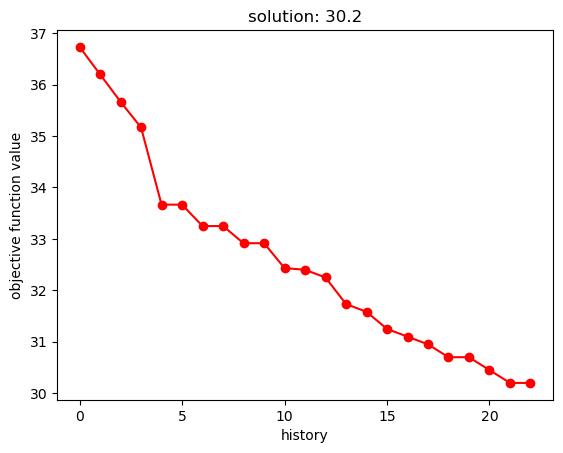

In [8]:
from gurobipy import GRB
import gurobipy as gp
import numpy as np
np.random.seed(0)
import math

class Instance(object):
    
    def __init__(self, num_order, min_order_len=10, max_order_len=50,
                min_demand=1, max_demand=5):
        
        # generates an instance which guarantees feasibility.
        self.n = num_order
        self.order_lens = np.random.randint(min_order_len, max_order_len+1, size=self.n)
        self.demands = np.random.randint(min_demand, max_demand+1, size=self.n)
        self.m = np.sum(self.demands)
        self.roll_len = max_order_len
    
    def summarize(self):
        print("Problem instance with ", self.n, " orders and ", self.m, "rolls")
        print("-"*47)
        print("\nOrders:\n")
        for i, order_len in enumerate(self.order_lens):
            print("\tOrder ", i, ": length= ", order_len, " demand=", self.demands[i])
        print("\nRoll Length: ", self.roll_len)

def optimize_kantorovich(ins_:Instance):
    
    # model
    model = gp.Model("kantorovich_formulation")
    
    # sets (ranges)
    rolls = range(ins_.m)
    orders = range(ins_.n)
    
    # decision variables
    use_roll = model.addVars(rolls,
                             vtype=GRB.BINARY,
                             obj=np.ones(ins_.m),
                             name="X")
    
    how_much_use = model.addVars(orders, rolls, 
                                 vtype=GRB.INTEGER,
                                 obj= np.zeros((ins_.n, ins_.m)), 
                                 name="Y")

    
    # direction of optimization (min or max)
    model.modelSense = GRB.MINIMIZE
    
    # demand satisfaction constraint
    model.addConstrs(
                    (how_much_use.sum(i, '*') == ins_.demands[i] for i in orders), 
                    "Demand"
                    )
    
    # length constraint of a roll
    for j in rolls:
        model.addConstr(sum(how_much_use[i,j]*ins_.order_lens[i] for i in orders)
                        <= ins_.roll_len,
                        "Length[%d]" %j)
    
    # x-y link
    for i in orders:
        for j in rolls:
            model.addConstr(how_much_use[i,j] <= use_roll[j]*ins_.demands[i])
    
    if False:
        model.write('kantorovich.lp') # in case you want to write the model
    
    # solve
    model.optimize()
    
    # display objective function value
    print('\nTotal Number of Rolls Used: ', model.objVal)

instance = Instance(20)
instance.summarize()

optimize_kantorovich(instance)

def generate_initial_patterns(ins_:Instance):
    patterns = []
    for i in range(ins_.n):
        pattern_ = list(np.zeros(ins_.n).astype(int))
        pattern_[i] = int(ins_.roll_len/ins_.order_lens[i])
        patterns.append(pattern_)
    return patterns

def define_master_problem(ins_:Instance, patterns):
    
    n_pattern = len(patterns)
    pattern_range = range(n_pattern)
    order_range = range(ins_.n)
    patterns = np.array(patterns, dtype=int)
    master_problem = gp.Model("master problem")
    
    # decision variables
    lambda_ = master_problem.addVars(pattern_range,
                                     vtype=GRB.CONTINUOUS,
                                     obj=np.ones(n_pattern),
                                     name="lambda")
    
    # direction of optimization (min or max)
    master_problem.modelSense = GRB.MINIMIZE
    
    # demand satisfaction constraint
    for i in order_range:
        master_problem.addConstr(sum(patterns[p,i]*lambda_[p] for p in pattern_range) == ins_.demands[i],
                                 "Demand[%d]" %i)
            
    # solve
    return master_problem


def define_subproblem(ins_:Instance, duals):
    
    order_range = range(ins_.n)
    subproblem = gp.Model("subproblem")
    #z
    # decision variables
    x = subproblem.addVars(order_range,
                           vtype=GRB.INTEGER,
                           obj=duals,
                           name="x")
    
    # subproblem optimization
    subproblem.modelSense = GRB.MAXIMIZE
        
    # Length constraint
    subproblem.addConstr(sum(ins_.order_lens[i] * x[i] for i in order_range) <= ins_.roll_len)
    
    return subproblem


def print_solution(master, patterns):
    use = [math.ceil(i.x) for i in master.getVars()]
    for i, p in enumerate(patterns):
        if use[i]>0:
            print('Pattern ', i, ': how often we should cut: ', use[i])
            print('----------------------')
            for j,order in enumerate(p):
                if order >0:
                    print('order ', j, ' how much: ', order)
            print()

def column_generation(ins_:Instance):
    
    patterns = generate_initial_patterns(ins_)
    objVal_history = []
    while True:
        master_problem = define_master_problem(ins_, patterns)
        master_problem.optimize()
        objVal_history.append(master_problem.objVal)
        dual_variables = np.array([constraint.pi for constraint in master_problem.getConstrs()])
        subproblem = define_subproblem(ins_, dual_variables)
        subproblem.optimize()
        if subproblem.objVal < 1 + 1e-2:
            break
        patterns.append([i.x for i in subproblem.getVars()])
    print_solution(master_problem, patterns)
    print('Total number of rolls used: ', int(np.array([math.ceil(i.x) for i in master_problem.getVars()]).sum()))
    return objVal_history


history = column_generation(instance)

import matplotlib.pyplot as plt
plt.plot(list(range(len(history))), history,c='r')
plt.scatter(list(range(len(history))), history, c='r')
plt.xlabel('history')
plt.ylabel('objective function value')
title = 'solution: ' + str(history[-1])
plt.title(title)
plt.show()

## initial feasible solution

In [10]:
from gurobipy import Model, GRB, quicksum
import math

# -------------------------------
# 1. Define the instance data
# -------------------------------
# List of companies
companies = ['Apple', 'Microsoft', 'Amazon', 'Alphabet', 'Meta', 'Tesla', 'JP', 'Berkshire']
n = len(companies)

# Cost per share for each company (for example)
cost = [110, 150, 160, 240, 120, 220, 80, 350]   # c_i for i=0,...,n-1

# Demand (number of shares required) for each company
demand = [30, 20, 50, 40, 35, 25,60, 15]  # D_i for i=0,...,n-1

# Maximum cost per package
package_limit = 1000

# -------------------------------
# 2. Generate initial patterns

# For each company, create a pattern that consists solely of that company:
# We take as many shares as possible of that company without exceeding package_limit.
patterns = []  # list of patterns; each pattern is a list of integers (shares per company)
for i in range(n):
    pattern = [0] * n
    max_shares = package_limit // cost[i]
    pattern[i] = max_shares
    patterns.append(pattern)

def pattern_cost(pattern):
    """Return total cost of a pattern."""
    total = 0
    for i in range(n):
        total += cost[i] * pattern[i]
    return total

# -------------------------------
# 3. Define the master problem

def solve_master(patterns):
    """
    Solve the master problem with the current set of patterns.
    Returns the model and a list of dual values for the demand constraints.
    """
    master = Model("Master")
    master.Params.OutputFlag = 0  # turn off solver output

    num_patterns = len(patterns)
    # Decision variables: lambda_p for each pattern p (fractional allowed)
    lambdas = []
    for p in range(num_patterns):
        # Cost of pattern p is the sum of cost[i]*pattern[i]
        pat_cost = pattern_cost(patterns[p])
        var = master.addVar(lb=0.0, obj=pat_cost, name="lambda_%d" % p)
        lambdas.append(var)
    master.update()

    # Demand constraints: for each company i, total shares from all patterns >= demand[i]
    for i in range(n):
        master.addConstr(quicksum(patterns[p][i] * lambdas[p] for p in range(num_patterns)) >= demand[i],
                          name="Demand_%d" % i)
    master.modelSense = GRB.MINIMIZE
    master.optimize()

    # Get duals for the demand constraints
    duals = []
    for i in range(n):
        constr = master.getConstrByName("Demand_%d" % i)
        duals.append(constr.Pi)
    return master, duals, lambdas

# -------------------------------
# 4. Define the subproblem (knapsack)

def solve_subproblem(duals):
    
    sub = Model("Subproblem")
    sub.Params.OutputFlag = 0  # no output

    # Decision variables: number of shares x[i] for company i in the new pattern
    x = []
    for i in range(n):
        var = sub.addVar(lb=0, vtype=GRB.INTEGER, name="x_%d" % i)
        x.append(var)
    sub.update()

    # Objective: maximize sum_i duals[i] * x[i]
    sub.setObjective(quicksum(duals[i] * x[i] for i in range(n)), GRB.MAXIMIZE)

    # Constraint: total cost in the package <= package_limit
    sub.addConstr(quicksum(cost[i] * x[i] for i in range(n)) <= package_limit, name="CostLimit")

    sub.optimize()

    # Extract the new pattern
    new_pattern = [int(x[i].X + 0.5) for i in range(n)]  # rounding to integer
    # Also compute the objective value of the subproblem
    sub_obj = sub.objVal
    return new_pattern, sub_obj

# -------------------------------
# 5. Column generation loop

tolerance = 1e-2
iteration = 0
while True:
    iteration += 1
    master, duals, lambdas = solve_master(patterns)
    # Solve subproblem with current dual prices
    new_pattern, sub_obj = solve_subproblem(duals)
    
    # Reduced cost: new_pattern cost - sub_obj; 
    # In column generation for minimization, if subproblem obj <= 1 then no column improves.
    # Here, note that the master objective coefficients are the cost of the pattern.
    # The reduced cost of a new column is: cost(new_pattern) - sum_i dual_i*x[i]
    new_pattern_cost = pattern_cost(new_pattern)
    reduced_cost = new_pattern_cost - sub_obj

    print("Iteration:", iteration, "New pattern:", new_pattern, 
          "Cost:", new_pattern_cost, "Subproblem obj:", sub_obj, 
          "Reduced cost:", reduced_cost)

    # If the reduced cost is not less than -tolerance, stop
    if reduced_cost >= -tolerance:
        break
    # Otherwise, add new pattern to the pool
    patterns.append(new_pattern)

# -------------------------------
# 6. Print final master solution

print("\nFinal Master Problem Solution:")
for i in range(n):
    lhs = sum(patterns[p][i] * lambdas[p].X for p in range(len(patterns)))
    print("Company", companies[i], ": Demand =", demand[i], "Achieved =", lhs)
total_cost = master.objVal
print("Total Cost:", total_cost)

# print the patterns used with nonzero lambda value.
print("\nPatterns used in the optimal solution:")
for p in range(len(patterns)):
    if lambdas[p].X > 1e-5:
        print("Pattern", p, ":", patterns[p], "lambda =", lambdas[p].X)


Iteration: 1 New pattern: [5, 3, 0, 0, 0, 0, 0, 0] Cost: 1000 Subproblem obj: 1000.0 Reduced cost: 0.0

Final Master Problem Solution:
Company Apple : Demand = 30 Achieved = 30.0
Company Microsoft : Demand = 20 Achieved = 20.0
Company Amazon : Demand = 50 Achieved = 50.0
Company Alphabet : Demand = 40 Achieved = 40.0
Company Meta : Demand = 35 Achieved = 35.0
Company Tesla : Demand = 25 Achieved = 25.0
Company JP : Demand = 60 Achieved = 60.0
Company Berkshire : Demand = 15 Achieved = 15.0
Total Cost: 43650.0

Patterns used in the optimal solution:
Pattern 0 : [9, 0, 0, 0, 0, 0, 0, 0] lambda = 3.3333333333333335
Pattern 1 : [0, 6, 0, 0, 0, 0, 0, 0] lambda = 3.3333333333333335
Pattern 2 : [0, 0, 6, 0, 0, 0, 0, 0] lambda = 8.333333333333334
Pattern 3 : [0, 0, 0, 4, 0, 0, 0, 0] lambda = 10.0
Pattern 4 : [0, 0, 0, 0, 8, 0, 0, 0] lambda = 4.375
Pattern 5 : [0, 0, 0, 0, 0, 4, 0, 0] lambda = 6.25
Pattern 6 : [0, 0, 0, 0, 0, 0, 12, 0] lambda = 5.0
Pattern 7 : [0, 0, 0, 0, 0, 0, 0, 2] lambda = 

## solution to the problem

In [12]:
import gurobipy as gp
from gurobipy import GRB
import math



def solve_portfolio_column_generation():

    # --------------------------
    # 1) Problem Data

    # We have 8 companies, each with a required demand (in shares) and a cost per share.
    # The total cost of shares in any package must not exceed 1000 USD.
    # Each purchased package (pattern) is assumed to cost 900 USD in the master problem.
    companies = ["Apple Inc", "Microsoft Corp", "Amazon.com Inc", "Alphabet Inc",
                 "Meta Platforms Inc", "Tesla Inc", "JPMorgan Chase", "Berkshire Hathaway"]
    
    demands = [30, 20, 50, 40, 35, 25, 60, 15]   # shares needed
    costs   = [110,150,160,240,120,220,80,350]     # cost per share (USD)

    n = len(companies)
    CAPACITY = 1000.0  # maximum total cost of shares per package
    PACKAGE_COST = 900.0  # fixed cost per package in the master problem

    # --------------------------
    # 2) Generate Initial Patterns

    def generate_initial_patterns():
        """
        Create a simple initial pattern set: 
        For each company i, put as many shares of that company alone 
        as fit into the 1000-USD capacity.
        """
        patterns = []
        for i in range(n):
            pattern = [0] * n
            max_shares = int(CAPACITY // costs[i])  # largest integer number of shares that fits
            if max_shares > 0:
                pattern[i] = max_shares
                patterns.append(pattern)
        return patterns
    

    # --------------------------
    # 3) Master Problem

    def define_master_problem(patterns):

        m = gp.Model("master_portfolio")
        m.setParam("OutputFlag", 0)  

        # Decision variables: fraction of each pattern to use (continuous)
        lambdas = []
        for p in range(len(patterns)):
            lambdas.append(
                m.addVar(
                    vtype=GRB.CONTINUOUS,
                    lb=0.0,
                    obj=PACKAGE_COST,  # each pattern costs 900 in the objective
                    name=f"lambda_{p}"
                )
            )

        m.modelSense = GRB.MINIMIZE
        m.update()

        # Demand constraints: for each company i, we need sum_{p} patterns[p][i]*lambda_p >= demands[i]
        for i in range(n):
            m.addConstr(
                gp.quicksum(patterns[p][i] * lambdas[p] for p in range(len(patterns))) >= demands[i],
                name=f"demand_{i}"
            )

        m.update()
        return m

    # --------------------------
    # 4) Subproblem

    def define_subproblem(duals):
        """
        Build an IP that chooses integer shares (how many shares of company i to put in a package),
        subject to sum_i(costs[i]*x_i) <= CAPACITY. 
        Objective: maximize sum_{i} (duals[i]*x_i).

        If the optimum is greater than PACKAGE_COST, then the reduced cost is negative,
        meaning we add that pattern.
        """
        sp = gp.Model("subproblem_package_design")
        sp.setParam("OutputFlag", 0)  # mute solver output

        # x[i] = number of shares of company i in the new pattern
        x = []
        for i in range(n):
            x.append(
                sp.addVar(vtype=GRB.INTEGER, lb=0, obj=duals[i], name=f"x_{i}")
            )

        sp.modelSense = GRB.MAXIMIZE
        sp.update()

        # Capacity constraint
        sp.addConstr(
            gp.quicksum(costs[i] * x[i] for i in range(n)) <= CAPACITY,
            name="capacity"
        )
        
        sp.update()
        return sp

    # --------------------------
    # Print the Initial Feasible Base
    # Generate the initial patterns and solve the master problem using them.
    
    initial_patterns = generate_initial_patterns()
    master_initial = define_master_problem(initial_patterns)
    master_initial.optimize()
    
    print("Initial Feasible Base:")
    lam_vars = master_initial.getVars()
    for p, lam in enumerate(lam_vars):
        if lam.X > 1e-6:
            print(f"  Pattern {p}: {initial_patterns[p]} used {lam.X:.3f} times")
    
    # Calculate total shares provided by the initial patterns
    total_shares = [0] * n
    for p, lam in enumerate(lam_vars):
        for i in range(n):
            total_shares[i] += initial_patterns[p][i] * lam.X
    
    print("\nShares Provided by Initial Feasible Base:")
    for i, comp in enumerate(companies):
        print(f"  {comp}: needed = {demands[i]}, bought = {total_shares[i]:.3f}")

    # --------------------------
    # 5) Column Generation

    def column_generation():
        # Start with some initial patterns
        patterns = generate_initial_patterns()
        obj_history = []
        iteration = 0

        while True:
            iteration += 1
            # Build and solve the current master problem
            master = define_master_problem(patterns)
            master.optimize()
            
            obj_val = master.objVal
            obj_history.append(obj_val)

            # Get duals from the demand constraints
            duals = [con.Pi for con in master.getConstrs()]

            # Solve the subproblem (knapsack) to find a new pattern
            sp = define_subproblem(duals)
            sp.optimize()
            sub_obj = sp.objVal

            # Extract new pattern from subproblem
            new_pattern = [int(v.X) for v in sp.getVars()]
            # Calculate the actual cost of the new pattern
            new_pattern_cost = sum(costs[i] * new_pattern[i] for i in range(n))
            # Compute reduced cost: difference between new pattern cost and subproblem obj
            reduced_cost = 900 - sub_obj

            # Print iteration information
            print("Iteration:", iteration,
                  "New pattern:", new_pattern,
                  "Cost:", new_pattern_cost,
                  "Subproblem obj:", sub_obj,
                  "Reduced cost:", reduced_cost)

            # Reduced cost check:
            # In the master, the pattern's cost is PACKAGE_COST.
            # If sub_obj <= PACKAGE_COST, no pattern with negative reduced cost exists.
            if sub_obj <= PACKAGE_COST + 1e-6:
                # No improvement -> stop column generation
                break
            else:
                # Otherwise, add the new pattern to the pool and iterate.
                patterns.append(new_pattern)

        return master, patterns, obj_history

    # --------------------------
    # 6) Run Column Generation

    master, patterns, obj_history = column_generation()
    master.optimize()

    # --------------------------
    # 7) Print Results

    print("Final Objective (Total Cost) =", master.objVal)
    print("Patterns used:")
    lam_vars = master.getVars()
    for p, lam in enumerate(lam_vars):
        if lam.X > 1e-6:
            print(f"  Pattern {p} is used {lam.X:.3f} times -> {patterns[p]}")

    # Calculate how many shares each pattern set provides and confirm demands are met.
    total_shares = [0] * n
    for p, lam in enumerate(lam_vars):
        for i in range(n):
            total_shares[i] += patterns[p][i] * lam.X

    print("\nShares Provided:")
    for i, comp in enumerate(companies):
        print(f"  {comp}: needed={demands[i]}, bought={total_shares[i]:.3f}")


solve_portfolio_column_generation()



Initial Feasible Base:
  Pattern 0: [9, 0, 0, 0, 0, 0, 0, 0] used 3.333 times
  Pattern 1: [0, 6, 0, 0, 0, 0, 0, 0] used 3.333 times
  Pattern 2: [0, 0, 6, 0, 0, 0, 0, 0] used 8.333 times
  Pattern 3: [0, 0, 0, 4, 0, 0, 0, 0] used 10.000 times
  Pattern 4: [0, 0, 0, 0, 8, 0, 0, 0] used 4.375 times
  Pattern 5: [0, 0, 0, 0, 0, 4, 0, 0] used 6.250 times
  Pattern 6: [0, 0, 0, 0, 0, 0, 12, 0] used 5.000 times
  Pattern 7: [0, 0, 0, 0, 0, 0, 0, 2] used 7.500 times

Shares Provided by Initial Feasible Base:
  Apple Inc: needed = 30, bought = 30.000
  Microsoft Corp: needed = 20, bought = 20.000
  Amazon.com Inc: needed = 50, bought = 50.000
  Alphabet Inc: needed = 40, bought = 40.000
  Meta Platforms Inc: needed = 35, bought = 35.000
  Tesla Inc: needed = 25, bought = 25.000
  JPMorgan Chase: needed = 60, bought = 60.000
  Berkshire Hathaway: needed = 15, bought = 15.000
Iteration: 1 New pattern: [0, 2, 0, 0, 0, 0, 0, 2] Cost: 1000 Subproblem obj: 1200.0 Reduced cost: -300.0
Iteration: 2 N